
# How many people have ever lived? A Bayesian prior-predictive model

**Method.** We use the standard three-input-class demographic accounting identity
(Fucks/Winkler/Keyfitz; Population Reference Bureau):

$$
\text{Total ever born} = P_{\text{start}} + \sum_{i} \text{CBR}_i \cdot \bar{P}_i \cdot \Delta t_i
$$

where for each historical interval $i$: $\text{CBR}_i$ is the crude birth rate
(births per 1,000 people per year), $\bar{P}_i$ is the average population during
the interval, and $\Delta t_i$ is its duration in years. $P_\text{start}$ is the
founding population at the start date, which is already "born" and must be
added once rather than derived from a birth rate.

**Why this is a prior-predictive simulation, not posterior inference.** There is
no observed data being conditioned on here — we are not updating beliefs against
a likelihood, we are *propagating* uncertainty in the inputs through a fixed,
known formula to get a distribution over the output. That is exactly what
`pm.sample_prior_predictive()` is for. Running `pm.sample()` (NUTS) on this model
would technically work but would be pointless — there is no likelihood term, so
the "posterior" would just be the prior, sampled far less efficiently than
direct forward simulation. This distinction also resolves the frequentist/Bayesian
question from before: there is no natural repeated-sampling frame for a
one-off historical quantity like this, so a *credible interval* built by
propagating explicit, stated prior uncertainty is the more coherent object than
a *confidence interval*.

**The three input classes, each given two prior families:**

1. **Starting date** for anatomically modern humans (~190,000–200,000 BCE)
2. **Population size** at a series of historical anchor points
3. **Crude birth rate (CBR)** for each interval between anchor points

**Two prior families compared:**

- **Log-normal** — supported on $(0, \infty)$, right-skewed, no upper bound.
  Standard choice for a positive quantity you know "to within a multiplicative
  factor." Its cost: it always assigns *some* probability, however small, to
  values arbitrarily far above your stated range — which can matter a lot once
  you multiply and sum a dozen of these together.
- **"Beta-ish"** — meaning a `Beta(α, β)` distribution *affinely rescaled* onto a
  hard-bounded interval `[low, high]` you choose from domain knowledge (e.g., a
  population can't plausibly have exceeded some historical carrying-capacity
  ceiling). We parameterize it by a target **mean** and a **concentration**
  parameter `κ` (higher = more tightly clustered around the mean), then convert
  to the corresponding `(α, β)`. Unlike log-normal, mass is *strictly zero*
  outside `[low, high]` — you are asserting the bound is real, not just unlikely
  to be exceeded.

Everything numeric below (population anchors, birth rates, ranges) is an
**illustrative starting point** loosely patterned on commonly-cited historical
population reconstructions (e.g. McEvedy & Jones' *Atlas of World Population
History*, UN World Population Prospects, and the PRB/Haub lineage) — not a
literature-vetted set of point estimates. Swap in your own researched values
before treating the output as more than a worked methodological example.


In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

%matplotlib inline

print("PyMC version:", pm.__version__)
assert pm.__version__.startswith("6."), "This notebook targets the PyMC 6.x API (written/tested against 6.3.1)."

RNG_SEED = 20240826
N_PRIOR_SAMPLES = 20_000

PyMC version: 6.3.1



## 1. Input data: population anchors and birth-rate intervals

`ANCHORS[0]` is the founding population at the (uncertain) start date — its
`year` is `None` because the start date is itself a random variable, handled
separately. Every other anchor has a fixed calendar year (astronomical year
numbering: negative = BCE) with an uncertain population.

`INTERVALS[j]` gives the crude birth rate between `ANCHORS[j]` and `ANCHORS[j+1]`.


In [2]:
ANCHORS = [
    dict(label="start_founding",   year=None,   pop_mean=1.0e4,  pop_low=1.0e3,  pop_high=1.0e5),
    dict(label="8000BCE_agri",     year=-8000,  pop_mean=5.0e6,  pop_low=1.0e6,  pop_high=1.0e7),
    dict(label="3000BCE_bronze",   year=-3000,  pop_mean=1.4e7,  pop_low=1.0e7,  pop_high=2.0e7),
    dict(label="1CE",              year=1,      pop_mean=3.0e8,  pop_low=1.7e8,  pop_high=4.0e8),
    dict(label="1000CE",           year=1000,   pop_mean=3.1e8,  pop_low=2.65e8, pop_high=3.45e8),
    dict(label="1500CE",           year=1500,   pop_mean=5.0e8,  pop_low=4.25e8, pop_high=5.4e8),
    dict(label="1650CE",           year=1650,   pop_mean=5.5e8,  pop_low=4.7e8,  pop_high=6.0e8),
    dict(label="1750CE",           year=1750,   pop_mean=8.0e8,  pop_low=7.2e8,  pop_high=9.5e8),
    dict(label="1850CE",           year=1850,   pop_mean=1.26e9, pop_low=1.20e9, pop_high=1.30e9),
    dict(label="1900CE",           year=1900,   pop_mean=1.65e9, pop_low=1.60e9, pop_high=1.70e9),
    dict(label="1950CE",           year=1950,   pop_mean=2.50e9, pop_low=2.45e9, pop_high=2.55e9),
    dict(label="2000CE",           year=2000,   pop_mean=6.10e9, pop_low=6.00e9, pop_high=6.20e9),
    dict(label="2024CE",           year=2024,   pop_mean=8.10e9, pop_low=8.00e9, pop_high=8.20e9),
]

INTERVALS = [
    dict(cbr_mean=80, cbr_low=60, cbr_high=95),   # founding -> 8000 BCE
    dict(cbr_mean=70, cbr_low=55, cbr_high=85),   # 8000 -> 3000 BCE
    dict(cbr_mean=60, cbr_low=45, cbr_high=75),   # 3000 BCE -> 1 CE
    dict(cbr_mean=55, cbr_low=40, cbr_high=70),   # 1 -> 1000 CE
    dict(cbr_mean=55, cbr_low=40, cbr_high=70),   # 1000 -> 1500 CE
    dict(cbr_mean=50, cbr_low=35, cbr_high=60),   # 1500 -> 1650 CE
    dict(cbr_mean=45, cbr_low=35, cbr_high=55),   # 1650 -> 1750 CE
    dict(cbr_mean=42, cbr_low=35, cbr_high=50),   # 1750 -> 1850 CE
    dict(cbr_mean=38, cbr_low=32, cbr_high=45),   # 1850 -> 1900 CE
    dict(cbr_mean=33, cbr_low=28, cbr_high=40),   # 1900 -> 1950 CE
    dict(cbr_mean=28, cbr_low=20, cbr_high=35),   # 1950 -> 2000 CE
    dict(cbr_mean=19, cbr_low=16, cbr_high=22),   # 2000 -> 2024 CE
]

assert len(INTERVALS) == len(ANCHORS) - 1


## 2. Prior-parameterization helpers

Both helpers take a **mean** and a **[low, high] range** (read as roughly a
90–95%-ish plausible band from your own judgment/literature) and return the
distribution parameters that reproduce that mean with that spread — so the
*inputs you reason about* (mean, plausible range) are the same for both prior
families, and only the *shape* (unbounded vs. hard-bounded) differs.


In [3]:
def lognormal_params(mean, low, high, z=1.96):
    '''(mu, sigma) for a LogNormal with the given arithmetic mean, calibrated
    so that [low, high] corresponds to roughly a central (1 - 2*Phi(-z)) interval
    (z=1.96 -> ~95%, z=1.645 -> ~90% one-sided).'''
    sigma = (np.log(high) - np.log(low)) / (2 * z)
    mu = np.log(mean) - 0.5 * sigma**2
    return mu, sigma


def betaish_params(mean, low, high, kappa=8.0):
    '''(alpha, beta) for a Beta distribution such that, after rescaling via
    low + (high - low) * Beta(alpha, beta), the result has the given mean and
    is supported ONLY on [low, high]. kappa = alpha + beta controls how tightly
    mass clusters around the mean (higher kappa -> narrower, more peaked).'''
    p = (mean - low) / (high - low)
    assert 0 < p < 1, "mean must lie strictly inside [low, high]"
    alpha = p * kappa
    beta_ = (1 - p) * kappa
    return alpha, beta_


## 3. Building the model

`build_model(prior_family, kappa)` constructs the full PyMC model for either
prior family. A few modeling notes:

- **Start date.** For log-normal, we can't put a LogNormal directly on a
  negative "astronomical year," so we instead model `extra_years_before_190kya`
  — how much earlier than 190,000 BCE the true origin might be — as LogNormal
  with a long right tail. This is a deliberate, realistic choice: genetic and
  fossil evidence (e.g. Jebel Irhoud) keeps pushing candidate dates for early
  *Homo sapiens* earlier, so an open-ended tail toward "even older than we
  thought" is scientifically defensible. The Beta-ish version instead treats
  190,000–200,000 BCE as a **hard** bound with no probability outside it —
  a stronger, more literal reading of "~190,000–200,000 BCE" as stated.
- **Average population per interval.** Assuming exponential (geometric) growth
  within an interval, the correct average of a quantity growing exponentially
  between $P_a$ and $P_b$ is the **logarithmic mean** $(P_b - P_a) / (\ln P_b - \ln P_a)$,
  not the arithmetic mean — we fall back to the arithmetic mean only in the
  degenerate case $P_a \approx P_b$ to avoid a 0/0.
- **Total.** `total_ever_born = founding population + sum of interval births.**
  Consistent with the demographic literature, this does **not** depend on death
  rates at all — only on births.


In [4]:
def logarithmic_mean(p_a, p_b):
    diff = p_b - p_a
    logdiff = pm.math.log(p_b) - pm.math.log(p_a)
    return pm.math.switch(pt.abs(diff) < 1.0, (p_a + p_b) / 2.0, diff / logdiff)


def build_model(prior_family="lognormal", kappa=8.0, z=1.96):
    assert prior_family in ("lognormal", "beta")

    with pm.Model() as model:

        # ---- Input class 1: starting date -----------------------------------
        if prior_family == "lognormal":
            mu_e, sigma_e = lognormal_params(mean=5000, low=200, high=10000, z=1.645)
            extra_years = pm.LogNormal("extra_years_before_190kya", mu=mu_e, sigma=sigma_e)
            start_year = pm.Deterministic("start_year", -190_000 - extra_years)
        else:
            a_s, b_s = betaish_params(mean=195_000, low=190_000, high=200_000, kappa=kappa)
            start_frac = pm.Beta("start_frac", alpha=a_s, beta=b_s)
            start_year = pm.Deterministic("start_year", -200_000 + start_frac * 10_000)

        # ---- Input class 2: population at each anchor -----------------------
        pops = []
        for i, a in enumerate(ANCHORS):
            name = f"pop_{i}_{a['label']}"
            if prior_family == "lognormal":
                mu_p, sigma_p = lognormal_params(a["pop_mean"], a["pop_low"], a["pop_high"], z=z)
                p_i = pm.LogNormal(name, mu=mu_p, sigma=sigma_p)
            else:
                al, be = betaish_params(a["pop_mean"], a["pop_low"], a["pop_high"], kappa=kappa)
                frac = pm.Beta(name + "_frac", alpha=al, beta=be)
                p_i = pm.Deterministic(name, a["pop_low"] + frac * (a["pop_high"] - a["pop_low"]))
            pops.append(p_i)

        # ---- Input class 3: birth rate for each interval, then births -------
        births_list = []
        for j, iv in enumerate(INTERVALS):
            name = f"cbr_{j}"
            if prior_family == "lognormal":
                mu_b, sigma_b = lognormal_params(iv["cbr_mean"], iv["cbr_low"], iv["cbr_high"], z=z)
                cbr = pm.LogNormal(name, mu=mu_b, sigma=sigma_b)
            else:
                al, be = betaish_params(iv["cbr_mean"], iv["cbr_low"], iv["cbr_high"], kappa=kappa)
                frac = pm.Beta(name + "_frac", alpha=al, beta=be)
                cbr = pm.Deterministic(name, iv["cbr_low"] + frac * (iv["cbr_high"] - iv["cbr_low"]))

            p_a, p_b = pops[j], pops[j + 1]
            year_a = start_year if j == 0 else ANCHORS[j]["year"]
            year_b = ANCHORS[j + 1]["year"]
            duration = year_b - year_a

            avg_pop = logarithmic_mean(p_a, p_b)
            births_j = pm.Deterministic(f"births_{j}", (cbr / 1000.0) * avg_pop * duration)
            births_list.append(births_j)

        total_births = pm.math.sum(pt.stack(births_list))
        total_ever_born = pm.Deterministic("total_ever_born", pops[0] + total_births)
        pct_alive_today = pm.Deterministic(
            "pct_alive_today", 100.0 * pops[-1] / total_ever_born
        )

    return model


## 4. Monte Carlo propagation (prior-predictive sampling)

This is the whole "Monte Carlo propagation" step: draw many independent samples
from all the priors, push each draw through the deterministic accounting
formula, and look at the resulting distribution of `total_ever_born`.


In [5]:
model_lognormal = build_model(prior_family="lognormal")
model_beta = build_model(prior_family="beta", kappa=8.0)

with model_lognormal:
    prior_lognormal = pm.sample_prior_predictive(draws=N_PRIOR_SAMPLES, random_seed=RNG_SEED)

with model_beta:
    prior_beta = pm.sample_prior_predictive(draws=N_PRIOR_SAMPLES, random_seed=RNG_SEED)

totals_ln = prior_lognormal.prior["total_ever_born"].values.flatten()
totals_be = prior_beta.prior["total_ever_born"].values.flatten()

pct_alive_ln = prior_lognormal.prior["pct_alive_today"].values.flatten()
pct_alive_be = prior_beta.prior["pct_alive_today"].values.flatten()

print(f"Lognormal draws: {totals_ln.shape[0]:,}   Beta-ish draws: {totals_be.shape[0]:,}")

Sampling: [cbr_0, cbr_1, cbr_10, cbr_11, cbr_2, cbr_3, cbr_4, cbr_5, cbr_6, cbr_7, cbr_8, cbr_9, extra_years_before_190kya, pop_0_start_founding, pop_10_1950CE, pop_11_2000CE, pop_12_2024CE, pop_1_8000BCE_agri, pop_2_3000BCE_bronze, pop_3_1CE, pop_4_1000CE, pop_5_1500CE, pop_6_1650CE, pop_7_1750CE, pop_8_1850CE, pop_9_1900CE]


Sampling: [cbr_0_frac, cbr_10_frac, cbr_11_frac, cbr_1_frac, cbr_2_frac, cbr_3_frac, cbr_4_frac, cbr_5_frac, cbr_6_frac, cbr_7_frac, cbr_8_frac, cbr_9_frac, pop_0_start_founding_frac, pop_10_1950CE_frac, pop_11_2000CE_frac, pop_12_2024CE_frac, pop_1_8000BCE_agri_frac, pop_2_3000BCE_bronze_frac, pop_3_1CE_frac, pop_4_1000CE_frac, pop_5_1500CE_frac, pop_6_1650CE_frac, pop_7_1750CE_frac, pop_8_1850CE_frac, pop_9_1900CE_frac, start_frac]


Lognormal draws: 20,000   Beta-ish draws: 20,000



## 5. Summary: credible intervals and comparison


In [6]:
def summarize(samples, label):
    billions = samples / 1e9
    hdi_94 = az.hdi(billions, prob=0.94)
    return {
        "prior family": label,
        "mean (B)": np.mean(billions),
        "median (B)": np.median(billions),
        "sd (B)": np.std(billions),
        "95% CI low (B)": np.percentile(billions, 2.5),
        "95% CI high (B)": np.percentile(billions, 97.5),
        "94% HDI low (B)": hdi_94[0],
        "94% HDI high (B)": hdi_94[1],
    }

summary_df = pd.DataFrame([
    summarize(totals_ln, "Log-normal"),
    summarize(totals_be, "Beta-ish"),
]).set_index("prior family").round(2)

summary_df

,mean (B),median (B),sd (B),95% CI low (B),95% CI high (B),94% HDI low (B),94% HDI high (B)
prior family,,,,,,,
Log-normal,84.43,83.29,9.46,69.29,105.87,68.34,102.05
Beta-ish,85.13,85.00,5.34,75.07,96.01,75.24,95.25


In [7]:
pct_alive_df = pd.DataFrame([
    {
        "prior family": "Log-normal",
        "mean % alive today": np.mean(pct_alive_ln),
        "95% CI low": np.percentile(pct_alive_ln, 2.5),
        "95% CI high": np.percentile(pct_alive_ln, 97.5),
    },
    {
        "prior family": "Beta-ish",
        "mean % alive today": np.mean(pct_alive_be),
        "95% CI low": np.percentile(pct_alive_be, 2.5),
        "95% CI high": np.percentile(pct_alive_be, 97.5),
    },
]).set_index("prior family").round(2)

pct_alive_df

,mean % alive today,95% CI low,95% CI high
prior family,,,
Log-normal,9.71,7.65,11.69
Beta-ish,9.55,8.43,10.79



## 6. Visual comparison


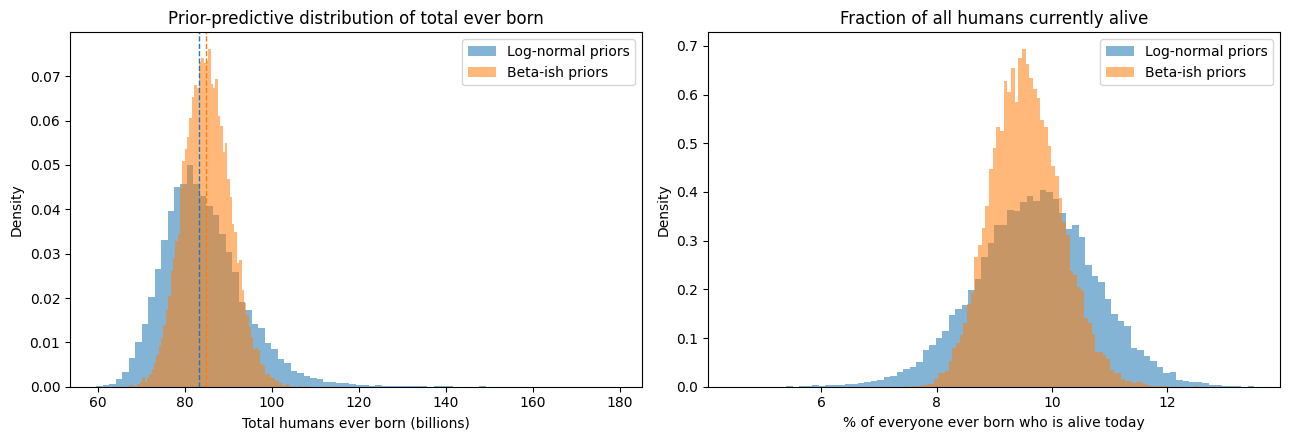

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(totals_ln / 1e9, bins=80, alpha=0.55, label="Log-normal priors", color="tab:blue", density=True)
axes[0].hist(totals_be / 1e9, bins=80, alpha=0.55, label="Beta-ish priors", color="tab:orange", density=True)
axes[0].axvline(np.median(totals_ln) / 1e9, color="tab:blue", linestyle="--", linewidth=1)
axes[0].axvline(np.median(totals_be) / 1e9, color="tab:orange", linestyle="--", linewidth=1)
axes[0].set_xlabel("Total humans ever born (billions)")
axes[0].set_ylabel("Density")
axes[0].set_title("Prior-predictive distribution of total ever born")
axes[0].legend()

axes[1].hist(pct_alive_ln, bins=80, alpha=0.55, label="Log-normal priors", color="tab:blue", density=True)
axes[1].hist(pct_alive_be, bins=80, alpha=0.55, label="Beta-ish priors", color="tab:orange", density=True)
axes[1].set_xlabel("% of everyone ever born who is alive today")
axes[1].set_ylabel("Density")
axes[1].set_title("Fraction of all humans currently alive")
axes[1].legend()

plt.tight_layout()
plt.show()


### Why the two families can diverge

The model multiplies and sums roughly a dozen independent uncertain quantities.
Log-normal's unbounded upper tail means that, purely by chance, a Monte Carlo
draw can combine several simultaneously-high values (a high founding population
*and* a high Paleolithic birth rate *and* an early start date) with no ceiling
stopping it — this tends to fatten the upper tail of `total_ever_born` and
widen the resulting credible interval, especially at the top end. The Beta-ish
family enforces hard stops on every input, so the same kind of compounding is
capped — expect its interval to be narrower, particularly the upper bound.
Check the `summary_df` output above to see the actual magnitude of this effect;
it's a good concrete illustration of how much a "minor" prior-shape choice can
matter once you're multiplying several uncertain quantities together.



## 7. Illustrating the shape difference directly (starting date)

This plots the two starting-date priors' densities analytically (not from
samples) so the bounded-vs-tailed distinction is visually obvious.


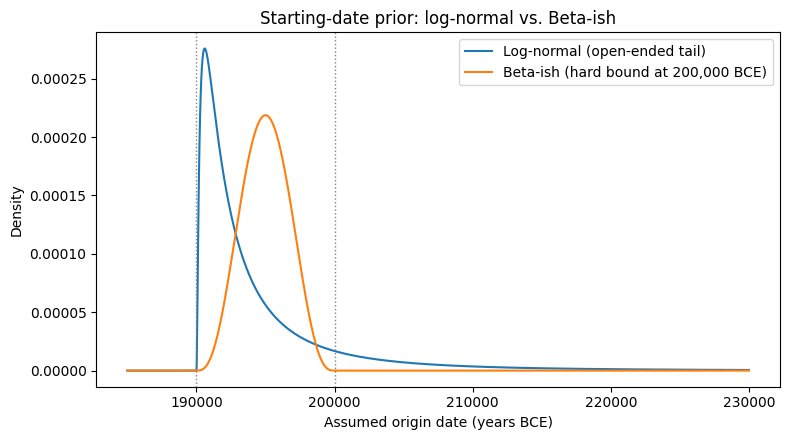

In [9]:
from scipy import stats

years_bce = np.linspace(185_000, 230_000, 2000)

mu_e, sigma_e = lognormal_params(mean=5000, low=200, high=10000, z=1.645)
extra = years_bce - 190_000
ln_density = np.where(
    extra > 0,
    stats.lognorm(s=sigma_e, scale=np.exp(mu_e)).pdf(extra),
    0.0,
)

a_s, b_s = betaish_params(mean=195_000, low=190_000, high=200_000, kappa=8.0)
frac = (years_bce - 190_000) / 10_000
beta_density = np.where(
    (frac >= 0) & (frac <= 1),
    stats.beta(a_s, b_s).pdf(np.clip(frac, 1e-9, 1 - 1e-9)) / 10_000,
    0.0,
)

plt.figure(figsize=(8, 4.5))
plt.plot(years_bce, ln_density, label="Log-normal (open-ended tail)", color="tab:blue")
plt.plot(years_bce, beta_density, label="Beta-ish (hard bound at 200,000 BCE)", color="tab:orange")
plt.axvline(190_000, color="gray", linestyle=":", linewidth=1)
plt.axvline(200_000, color="gray", linestyle=":", linewidth=1)
plt.xlabel("Assumed origin date (years BCE)")
plt.ylabel("Density")
plt.title("Starting-date prior: log-normal vs. Beta-ish")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Takeaways and next steps

- **This is a methodology demonstration, not a finished estimate.** The anchor
  populations and birth rates are illustrative placeholders. Before treating
  the output numbers as meaningful, replace `ANCHORS` and `INTERVALS` with
  values you've actually sourced (McEvedy & Jones, UN WPP, Livi-Bacci, the
  PRB/Haub CBR-by-era table, Kremer 1993, etc.), and set the `[low, high]`
  ranges to reflect the actual disagreement across sources for each period,
  not a guessed spread.
- **The credible interval is only as good as the prior elicitation.** Because
  this is a forward simulation with no data to correct it, there's no "learning"
  step — garbage in, garbage out, with a nice-looking histogram around it. The
  main value of doing it this way over a single point estimate is that it forces
  you to be explicit about *which* uncertainties you think matter and by how
  much, and shows you which of the ~25 uncertain inputs actually drives the
  width of the final interval (worth checking via a one-at-a-time sensitivity
  sweep, or by inspecting posterior... — here, prior — correlations between
  each input and `total_ever_born`).
- **kappa is a knob, not a law of nature.** The Beta-ish family's `kappa`
  controls how "confident" each bounded prior is; try a few values (e.g. 4 vs
  8 vs 20) and see how much the final interval moves — that sensitivity is
  itself informative.
- **Possible extensions:** (1) replace the single-point CBR-per-interval with
  its own uncertain trajectory rather than a constant within each interval;
  (2) add a stochastic/jump component to population trajectories to capture
  plagues and famines rather than assuming smooth exponential interpolation
  between anchors; (3) treat some anchors (e.g. 2024 population) as
  effectively known constants rather than random, since we do have that data
  precisely, tightening the overall interval without changing the method.
